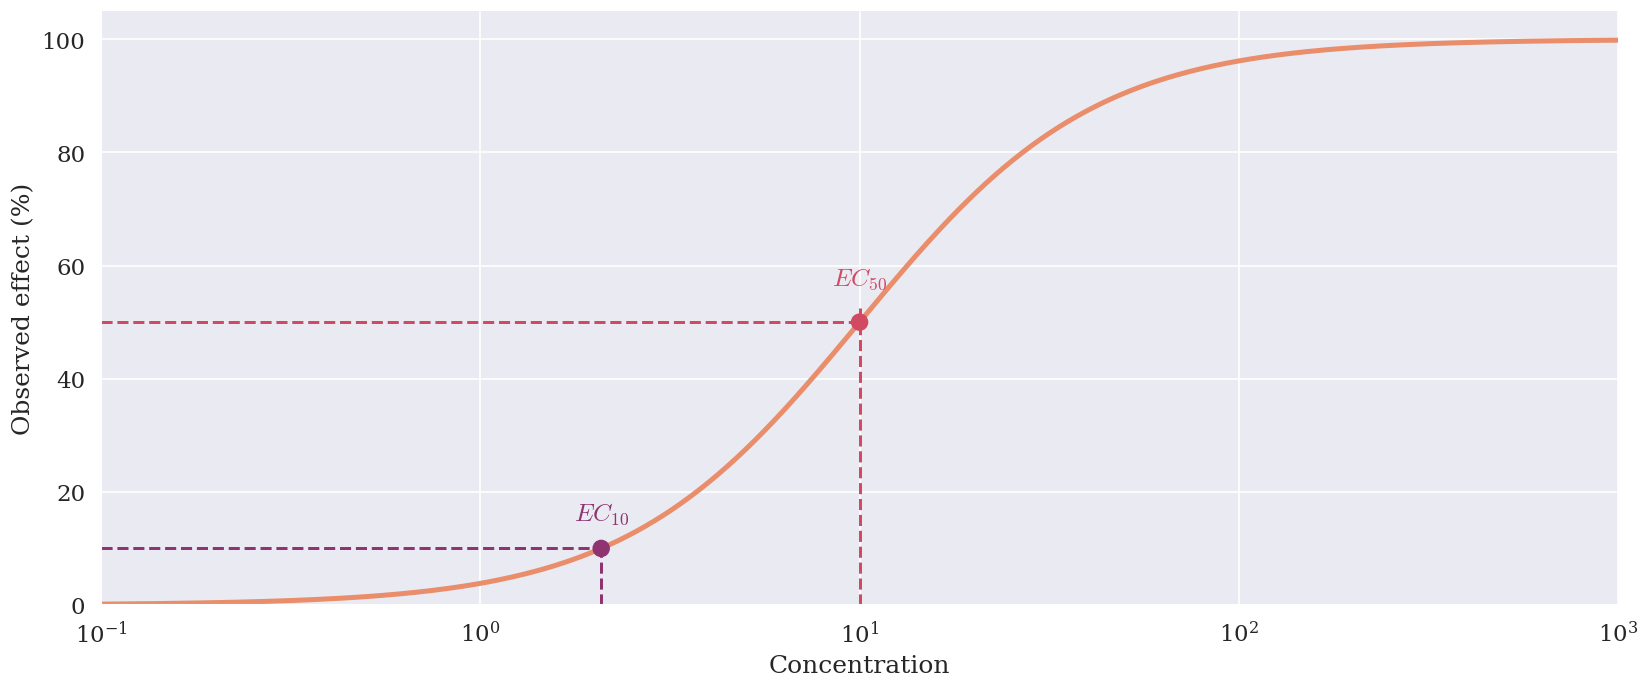

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

figsize = (14, 6)

n_colors = 6
project_palette = sns.color_palette("flare_r", n_colors=n_colors)

sns.set_theme(
    style="darkgrid",
    font="serif",
    font_scale=1.25,
    rc={
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": [
            "CMU Serif",
            "Computer Modern Roman",
            "Latin Modern Roman",
            "DejaVu Serif"
        ],
        "mathtext.fontset": "cm",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
    },
    palette=project_palette
)

# Example dose-response parameters
EC50 = 10
hill_slope = 1.4
max_response = 100

concentration = np.logspace(-1, 3, 500)

response = max_response / (
    1 + (EC50 / concentration) ** hill_slope
)

def ecx(x, EC50, hill_slope):
    return EC50 * (x / (1 - x)) ** (1 / hill_slope)

EC10 = ecx(0.10, EC50, hill_slope)

fig, ax = plt.subplots(figsize=figsize)

curve_color = project_palette[5]
ec10_color = project_palette[1]
ec50_color = project_palette[3]

ax.plot(
    concentration,
    response,
    linewidth=3,
    color=curve_color,
    label="Dose-response curve"
)

# Normalize x positions for partial horizontal guide lines
xmin, xmax = concentration.min(), concentration.max()

ec10_xmax = (np.log10(EC10) - np.log10(xmin)) / (np.log10(xmax) - np.log10(xmin))
ec50_xmax = (np.log10(EC50) - np.log10(xmin)) / (np.log10(xmax) - np.log10(xmin))

# EC10 guide lines
ax.axhline(
    10,
    xmax=ec10_xmax,
    linestyle="--",
    linewidth=1.8,
    color=ec10_color
)

ax.axvline(
    EC10,
    ymax=10 / max_response,
    linestyle="--",
    linewidth=1.8,
    color=ec10_color
)

# EC50 guide lines
ax.axhline(
    50,
    xmax=ec50_xmax,
    linestyle="--",
    linewidth=1.8,
    color=ec50_color
)

ax.axvline(
    EC50,
    ymax=50 / max_response,
    linestyle="--",
    linewidth=1.8,
    color=ec50_color
)

# Points
ax.scatter(
    [EC10, EC50],
    [10, 50],
    s=90,
    color=[ec10_color, ec50_color],
    zorder=5
)

# Text labels
ax.text(
    EC10,
    14,
    r"$EC_{10}$",
    ha="center",
    va="bottom",
    color=ec10_color,
)

ax.text(
    EC50,
    55.5,
    r"$EC_{50}$",
    ha="center",
    va="bottom",
    color=ec50_color
)

ax.set_xscale("log")
ax.set_xlabel("Concentration")
ax.set_ylabel("Observed effect (%)")

ax.set_ylim(0, 105)
ax.set_xlim(xmin, xmax)

sns.despine()
plt.tight_layout()
plt.show()

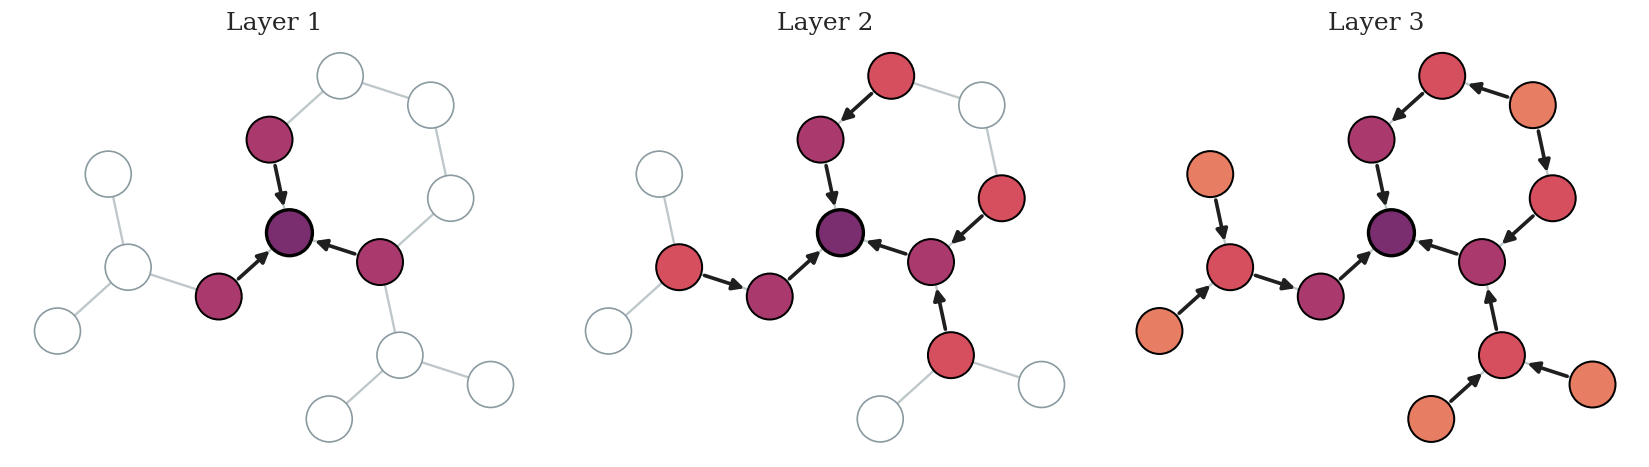

In [43]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx


from rdkit import Chem
from rdkit.Chem import rdDepictor

n_colors = 4
project_palette = sns.color_palette("flare", n_colors=n_colors)

target_color_index = n_colors - 1
farthest_color_index = 0
target_color = project_palette[target_color_index]


def _message_passing_color(distance, max_distance):
    if distance == 0:
        return project_palette[target_color_index]

    denominator = max(max_distance, 1)
    palette_idx = round(
        target_color_index
        + (farthest_color_index - target_color_index) * (distance / denominator)
    )
    palette_idx = max(0, min(palette_idx, len(project_palette) - 1))

    return project_palette[palette_idx]


frontier_color = _message_passing_color(1, 3)
inner_color = _message_passing_color(2, 3)
inactive_color = "white"
edge_color = "#8a9aa0"
active_edge_color = "#1f1f1f"


def _output_path(filename):
    cwd = Path.cwd().resolve()
    root = cwd.parent if cwd.name == "notebooks" else cwd
    path = root / "outputs" / "figures" / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def _bracket_atom_symbol(token):
    body = token[1:-1].lstrip("0123456789")
    if not body:
        return "*"
    if len(body) >= 2 and body[0].isupper() and body[1].islower():
        return body[:2]
    if body[0].isalpha():
        return body[0].upper()
    return "*"


def _fallback_smiles_to_nx(smiles):
    """Small SMILES topology parser for plotting when RDKit is unavailable."""
    two_letter_atoms = {"Cl", "Br"}
    aromatic_atoms = {"b", "c", "n", "o", "p", "s"}
    bond_symbols = {"-", "=", "#", ":", "/", "\\"}

    graph = nx.Graph()
    branch_stack = []
    ring_openings = {}
    previous_atom = None
    pending_bond = "-"
    atom_idx = 0
    i = 0

    def add_atom(symbol):
        nonlocal atom_idx, previous_atom, pending_bond
        current_atom = atom_idx
        graph.add_node(current_atom, element=symbol)
        if previous_atom is not None:
            graph.add_edge(previous_atom, current_atom, bond_type=pending_bond)
        previous_atom = current_atom
        atom_idx += 1
        pending_bond = "-"

    while i < len(smiles):
        char = smiles[i]

        if char == "[":
            end = smiles.find("]", i)
            if end == -1:
                raise ValueError(f"Unclosed bracket atom in SMILES: {smiles}")
            add_atom(_bracket_atom_symbol(smiles[i:end + 1]))
            i = end + 1
            continue

        if smiles[i:i + 2] in two_letter_atoms:
            add_atom(smiles[i:i + 2])
            i += 2
            continue

        if char.isupper() or char in aromatic_atoms:
            add_atom(char.upper())
            i += 1
            continue

        if char in bond_symbols:
            pending_bond = char
            i += 1
            continue

        if char == "(":
            branch_stack.append(previous_atom)
            i += 1
            continue

        if char == ")":
            if not branch_stack:
                raise ValueError(f"Unmatched branch close in SMILES: {smiles}")
            previous_atom = branch_stack.pop()
            i += 1
            continue

        if char == ".":
            previous_atom = None
            i += 1
            continue

        if char.isdigit() or char == "%":
            if previous_atom is None:
                raise ValueError(f"Ring marker has no preceding atom in SMILES: {smiles}")
            if char == "%":
                ring_id = smiles[i + 1:i + 3]
                i += 3
            else:
                ring_id = char
                i += 1
            if ring_id in ring_openings:
                graph.add_edge(ring_openings.pop(ring_id), previous_atom, bond_type=pending_bond)
                pending_bond = "-"
            else:
                ring_openings[ring_id] = previous_atom
            continue

        i += 1

    if ring_openings:
        raise ValueError(f"Unclosed ring marker(s) in SMILES: {smiles}")
    if graph.number_of_nodes() == 0:
        raise ValueError(f"No atoms found in SMILES: {smiles}")

    return graph


def _rdkit_smiles_to_nx(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Could not parse SMILES: {smiles}")

    rdDepictor.Compute2DCoords(mol)
    conformer = mol.GetConformer()
    graph = nx.Graph()
    positions = {}

    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        point = conformer.GetAtomPosition(idx)
        graph.add_node(idx, element=atom.GetSymbol())
        positions[idx] = (point.x, point.y)

    for bond in mol.GetBonds():
        graph.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=bond.GetBondTypeAsDouble(),
        )

    return graph, positions


def smiles_to_nx(smiles):
    if Chem is not None:
        return _rdkit_smiles_to_nx(smiles)

    graph = _fallback_smiles_to_nx(smiles)
    if graph.number_of_nodes() == 1:
        positions = {next(iter(graph.nodes)): (0.0, 0.0)}
    else:
        positions = nx.kamada_kawai_layout(graph)
    return graph, positions


def _directed_edges_toward_target(graph, target_atom_idx, active_nodes, distances):
    directed_edges = []
    for u, v in graph.edges:
        if u not in active_nodes or v not in active_nodes:
            continue
        u_distance = distances.get(u)
        v_distance = distances.get(v)
        if u_distance == v_distance + 1:
            directed_edges.append((u, v))
        elif v_distance == u_distance + 1:
            directed_edges.append((v, u))
    return directed_edges


def plot_message_passing_layers(smiles, target_atom_idx=None, n_layers=3, save_path=None):
    graph, positions = smiles_to_nx(smiles)

    if target_atom_idx is None:
        target_atom_idx = max(
            graph.nodes,
            key=lambda node: len(nx.single_source_shortest_path_length(graph, node, cutoff=n_layers)),
        )
    if target_atom_idx not in graph:
        raise ValueError(
            f"target_atom_idx={target_atom_idx} is not in the graph. "
            f"Choose one of {sorted(graph.nodes)}."
        )

    distances = nx.single_source_shortest_path_length(graph, target_atom_idx)
    hop_colors = {
        distance: _message_passing_color(distance, n_layers)
        for distance in range(n_layers + 1)
    }
    labels = {
        node: f"{graph.nodes[node].get('element', '')}{node}"
        for node in graph.nodes
    }

    fig, axes = plt.subplots(1, n_layers, figsize=(14, 5.2))
    if n_layers == 1:
        axes = [axes]

    for layer, ax in enumerate(axes, start=1):
        active_nodes = {
            node for node, distance in distances.items()
            if distance <= layer
        }
        active_edges = _directed_edges_toward_target(
            graph, target_atom_idx, active_nodes, distances
        )

        node_colors = []
        node_edgecolors = []
        node_linewidths = []

        for node in graph.nodes:
            if node in active_nodes:
                node_distance = distances[node]
                node_colors.append(hop_colors[node_distance])
                node_edgecolors.append("black")
                node_linewidths.append(2.0 if node == target_atom_idx else 1.2)
            else:
                node_colors.append(inactive_color)
                node_edgecolors.append(edge_color)
                node_linewidths.append(1.0)

        nx.draw_networkx_edges(
            graph,
            positions,
            ax=ax,
            edge_color=edge_color,
            width=1.4,
            alpha=0.55,
        )

        directed_graph = nx.DiGraph()
        directed_graph.add_nodes_from(graph.nodes)
        directed_graph.add_edges_from(active_edges)
        nx.draw_networkx_edges(
            directed_graph,
            positions,
            edgelist=active_edges,
            ax=ax,
            edge_color=active_edge_color,
            width=2.2,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=14,
            min_source_margin=16,
            min_target_margin=16,
        )

        nx.draw_networkx_nodes(
            graph,
            positions,
            ax=ax,
            node_color=node_colors,
            edgecolors=node_edgecolors,
            linewidths=node_linewidths,
            node_size=760,
        )
        # nx.draw_networkx_labels(
        #     graph,
        #     positions,
        #     labels=labels,
        #     ax=ax,
        #     # font_size=8.5,
        #     font_family="serif",
        # )

        ax.set_title(f"Layer {layer}")
        ax.set_aspect("equal")
        ax.axis("off")
    
    fig.tight_layout(rect=(0, 0.08, 1, 0.98))

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig, axes


example_smiles = "CC(=O)Oc1ccccc1C(=O)O"
target_atom_idx = 4

fig, axes = plot_message_passing_layers(
    example_smiles,
    target_atom_idx=target_atom_idx,
    n_layers=3,
    # save_path=_output_path("message_passing_graph.jpg"),
)
plt.show()
